In [1]:
#1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#2
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize

In [3]:
#3
DATASET_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3

In [4]:
# CELL 4 — Train / Val / Test Split (70/10/20)

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)

# 70% TRAIN
train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# 30% TEMP (will split into val + test manually)
temp_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

Found 788 images belonging to 3 classes.
Found 336 images belonging to 3 classes.


In [5]:
#  CELL — Split TEMP into VAL (10%) and TEST (20%)

from sklearn.model_selection import train_test_split

X = temp_data.filepaths
y = temp_data.classes

# Split 30% → 10% val + 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X, y, test_size=2/3, random_state=42, stratify=y
)

print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Validation size: 112
Test size: 224


In [6]:
# CELL 5 — VGG16 Model Creation

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load pre-trained VGG16 (without top)
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze base layers
for layer in vgg_base.layers:
    layer.trainable = False

# Custom classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Final model
model = Model(inputs=vgg_base.input, outputs=output)

# Compile (same settings as other models)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
# CELL 6 — Training

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=temp_data,
    epochs=EPOCHS
)

training_time = time.time() - start_time
print("Training time (sec):", training_time)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 380s 15s/step - accuracy: 0.3477 - loss: 1.2071 - val_accuracy: 0.4702 - val_loss: 1.0616
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 290ms/step - accuracy: 0.4099 - loss: 1.0935 - val_accuracy: 0.5238 - val_loss: 1.0415
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 295ms/step - accuracy: 0.4556 - loss: 1.0432 - val_accuracy: 0.5298 - val_loss: 1.0278
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step - accuracy: 0.4937 - loss: 0.9967 - val_accuracy: 0.5357 - val_loss: 1.0159
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.5102 - loss: 0.9721 - val_accuracy: 0.5149 - val_loss: 1.0059
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 325ms/step - accuracy: 0.5609 - loss: 0.9245 - val_accuracy: 0.5476 - val_loss: 0.9971
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 332ms/step - accuracy: 0.6218 - loss: 0.8665 - val_accuracy: 0.5327 - val_loss: 0.9897
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 319ms/step - accuracy: 0.6104 - loss: 0.8594 - val_accuracy: 0.

In [8]:
# CELL 7: Testing

start_test = time.time()

y_pred_probs = model.predict(temp_data)

testing_time = time.time() - start_test

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = temp_data.classes

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step


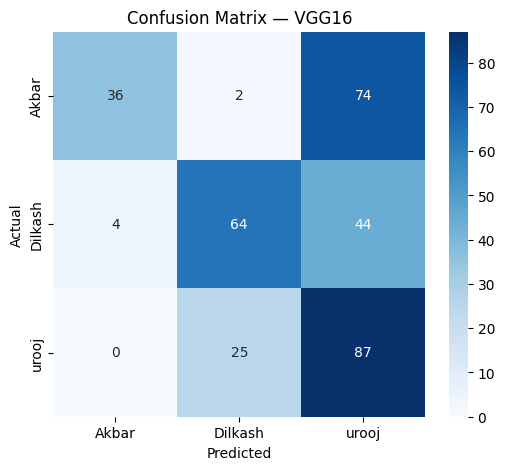

Class Akbar Accuracy: 0.3214
Class Dilkash Accuracy: 0.5714
Class urooj Accuracy: 0.7768


In [9]:
# CELL 8 — Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — VGG16")
plt.show()

class_acc = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(class_acc):
    print(f"Class {class_names[i]} Accuracy: {acc:.4f}")

In [10]:
# CELL 9 — Classification Report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

       Akbar     0.9000    0.3214    0.4737       112
     Dilkash     0.7033    0.5714    0.6305       112
       urooj     0.4244    0.7768    0.5489       112

    accuracy                         0.5565       336
   macro avg     0.6759    0.5565    0.5510       336
weighted avg     0.6759    0.5565    0.5510       336



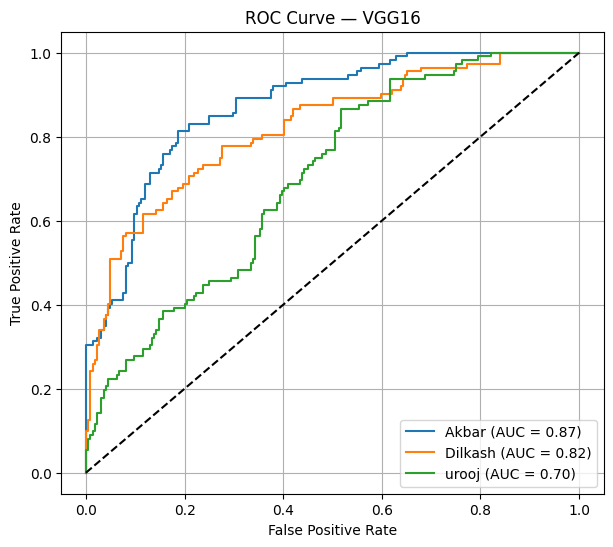

In [11]:
# CELL 10 — ROC & AUC

num_classes = NUM_CLASSES
y_true_bin = label_binarize(y_true, classes=range(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — VGG16")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# CELL 11 — Metrics

test_accuracy = accuracy_score(y_true, y_pred)

# Extract weighted avg metrics
lines = report.split('\n')
weighted_avg = [l for l in lines if 'weighted avg' in l][0].split()

precision = float(weighted_avg[2])
recall = float(weighted_avg[3])
f1 = float(weighted_avg[4])

print("Testing Time (sec):", testing_time)

vgg_results = {
    "Model": "VGG16",
    "Accuracy": test_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "AUC (Avg)": np.mean(list(roc_auc.values())),
    "Training Time (sec)": training_time,
    "Testing Time (sec)": testing_time
}

vgg_results

Testing Time (sec): 3.855916976928711


{'Model': 'VGG16',
 'Accuracy': 0.5565476190476191,
 'Precision': 0.6759,
 'Recall': 0.5565,
 'F1-score': 0.551,
 'AUC (Avg)': np.float64(0.7989742772108843),
 'Training Time (sec)': 783.0392854213715,
 'Testing Time (sec)': 3.855916976928711}

In [13]:
# CELL 12: Save Results

import numpy as np
import pandas as pd
import os

SAVE_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Task2_Results"
os.makedirs(SAVE_PATH, exist_ok=True)

# Conversion predictions to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = temp_data.classes
# 1 = correct, 0 = wrong
correct_array = (y_pred_classes == y_true_classes).astype(int)

MODEL_NAME = "VGG16"

np.save(f"{SAVE_PATH}/{MODEL_NAME}_correct.npy", correct_array)

# metrics
metrics_df = pd.DataFrame({
    "Accuracy": [test_accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "AUC": [np.mean(list(roc_auc.values()))],
    "Training Time (sec)": [training_time],
    "Testing Time (sec)": [testing_time]
})

metrics_df.to_csv(f"{SAVE_PATH}/{MODEL_NAME}_metrics.csv", index=False)

print("Saved results for", MODEL_NAME)

Saved results for VGG16
